In [1]:
import os, sys
os.environ['CUDA_VISIBLE_DEVICES'] = '0,1'

import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from gofish import imagecube
from ruamel.yaml import YAML

sys.path.insert(0, '../')
import visualization, sensor, grid, line_rte, parametric_disk
from network import shard
from consts import *
import emcee
from functools import partial
import time

In [2]:
################################################################################
# 1) Create the disk_params dictionary (instead of DiskFlaherty object).
################################################################################
disk_params = parametric_disk.create_disk_params(
    q=-0.27,
    q_in=-0.57,
    r_break=70,
    log_r_c=2.3,
    v_turb=0.06,
    T_atm1=87.0,
    gamma=1.0,
    T_mid1=17.8,
    M_star=2.3 * M_sun,
    r_in=11.0,
    M_gas=0.09 * M_sun,
    co_abundance=1e-4,
    N_dissoc=0.79 * 1.59e21,
    N_desorp=-np.inf,
    freezeout=19.0,
    r_scale=150.0,
    z_q0=70.0,
    delta=1,
    transition=2,
    m_mol=2.37 * m_h,
)

noise_sigma = 0.05  # 5% of the maximum intensity

In [3]:
################################################################################
# 2) Build the disk grid (z and r) for computing temperature, densities, etc.
################################################################################
resolution = 500
z_min, z_max = 0, 200
r_min, r_max = disk_params['r_in'], 800
z_disk, r_disk = jnp.meshgrid(
    jnp.linspace(z_min, z_max, resolution), 
    jnp.linspace(r_min, r_max, resolution), 
    indexing='ij'
)
molecular_table = "/nfs/rhea.dgp/u8/d/len/code/radjax_updated/molecular_tables/molecule_12c16o.inp"

2025-01-06 08:44:15.845810: W external/xla/xla/service/gpu/nvptx_compiler.cc:930] The NVIDIA driver's CUDA version is 12.4 which is older than the PTX compiler version 12.6.77. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


In [4]:
################################################################################
# 3) Use the functional approach to compute temperature, number density, velocity
################################################################################
temperature = parametric_disk.temperature_profile(z_disk, r_disk, disk_params)

nd_h2 = parametric_disk.number_density_profile(
    z_disk, 
    r_disk, 
    temperature,
    disk_params['gamma'],
    disk_params['r_in'],
    10 ** disk_params['log_r_c'],
    disk_params['M_gas'],
    disk_params['M_star'],
    disk_params['m_mol']
)

velocity_az = parametric_disk.velocity_profile(
    z_disk, 
    r_disk, 
    nd_h2, 
    temperature, 
    disk_params
)

In [5]:
################################################################################
# 4) Compute column density, CO abundance, etc. (still purely functional)
################################################################################
N_h2 = parametric_disk.surface_density(z_disk, nd_h2)
sigma_h2 = N_h2 * m_h

abundance_co = parametric_disk.co_abundance_profile(N_h2, temperature, disk_params)
nd_co = abundance_co * nd_h2


In [6]:
################################################################################
# 5) Prepare bounding box for interpolation
################################################################################
bbox_disk = jnp.array([(au*z_min, au*z_max), (au*r_min, au*r_max)])


In [7]:
################################################################################
# 6) Define the rendering functions in a functional style
################################################################################
def render_cube_pinhole(ray_coords, pixel_area, disk_params, nd_co, temperature, velocity_az, bbox, freqs, nu0, obs_dir, molecular_table):
    ray_coords_sph = grid.cartesian_to_spherical(ray_coords)
    ray_coords_polar = grid.spherical_to_zr(ray_coords_sph)

    # Interpolate dataset along the ray coordinates
    gas_nd = grid.interpolate_scalar(nd_co, ray_coords_polar, bbox)
    gas_t  = grid.interpolate_scalar(temperature, ray_coords_polar, bbox, cval=1e-10)
    gas_v_az = grid.interpolate_scalar(velocity_az, ray_coords_polar, bbox)
    gas_v = parametric_disk.azimuthal_velocity(ray_coords, gas_v_az)

    # Load molecular data from disk_params
    energy_levels, radiative_transitions = line_rte.load_molecular_tables(path=molecular_table)
    _, a_ud, b_ud, b_du = line_rte.einstein_coefficients(
        energy_levels, radiative_transitions, transition=disk_params['transition']
    )
    n_up, n_dn = line_rte.n_up_down(
        gas_nd, gas_t, energy_levels, radiative_transitions, transition=disk_params['transition']
    )
    alpha_tot = line_rte.alpha_total_co(disk_params['v_turb'], gas_t)

    print(f'computing pinhole spectral cube for a total of {freqs.size} frequencies')
    images = line_rte.compute_spectral_cube_pmap(
        shard(freqs), gas_v, alpha_tot, n_up, n_dn,
        a_ud, b_ud, b_du, ray_coords, obs_dir, nu0, pixel_area
    )
    images = np.nan_to_num(images).reshape(freqs.size, *ray_coords.shape[:2])
    return images

In [8]:
################################################################################
# 7) Example usage: generating pinhole and orthographic projections
################################################################################
# Pinhole Projection Setup
fov_as = 14.0  # arcsecs
data_path = '~/code/radjax/data/alma/HD163296_CO_highres_cen.cm.fits'
data_path = '/scratch/ondemand28/len/data/radjax/MAPS/HD_163296_CO_220GHz.0.2arcsec.image.fits'
data_cube = imagecube(data_path, FOV=fov_as)

num_freqs_resample = 20
num_freqs = len(data_cube.freqax)
idx = np.round(np.linspace(0, num_freqs - 1, num_freqs_resample)).astype(int)

data = data_cube.data[idx]
freqs = data_cube.freqax[idx]
velocities = data_cube.velax[idx]
x_sky, y_sky = np.meshgrid(data_cube.xaxis, data_cube.yaxis, indexing='xy')
nu0 = data_cube.nu0  # e.g. 230.538 GHz
npix = data_cube.nxpix
width_kms = (velocities[-1] - velocities[0]) / 1000.0
if num_freqs_resample > 1:
    delta_v_ms = velocities[1] - velocities[0]
else: 
    delta_v_ms = np.inf
print(f'velocity resolution: {delta_v_ms} m/s')

# Shift frequencies so that center is ~nu0
freqs += nu0 - freqs.mean()

projection_pinhole = sensor.PinholeProjection(
    name='HD163296',
    x_sky=x_sky,
    y_sky=y_sky,
    distance=122.0,
    nray=100,
    incl=47.5,
    phi=0.0,
    posang=312.0,
    z_width=2 * z_max,
    freqs=freqs
)

fov_rad = fov_as * arcsec
fov = 2 * projection_pinhole.distance * pc * np.tan(fov_rad / 2.0)
pixel_area_pinhole = (fov / npix) ** 2

ray_coords_pinhole, obs_dir_pinhole = sensor.pinhole_disk_projection(
    projection_pinhole.x_sky,
    projection_pinhole.y_sky,
    projection_pinhole.distance,
    projection_pinhole.nray,
    projection_pinhole.incl,
    projection_pinhole.phi,
    projection_pinhole.posang,
    projection_pinhole.z_width
)

velocity resolution: 1399.9999998642998 m/s


In [9]:
data_cube.data.shape

(127, 702, 702)

In [10]:
################################################################################
# 8) Render the cubes via the new functional approach
################################################################################
images = render_cube_pinhole(
    ray_coords_pinhole,
    pixel_area_pinhole,
    disk_params,
    nd_co,
    temperature,
    -velocity_az,  # note sign convention
    bbox_disk,
    freqs=freqs,
    nu0=nu0,
    obs_dir=obs_dir_pinhole,
    molecular_table=molecular_table
)

computing pinhole spectral cube for a total of 20 frequencies


2025-01-06 08:44:38.669025: W external/xla/xla/tsl/framework/bfc_allocator.cc:497] Allocator (GPU_0_bfc) ran out of memory trying to allocate 12.33GiB (rounded to 13242629888)requested by op 
2025-01-06 08:44:38.669356: W external/xla/xla/tsl/framework/bfc_allocator.cc:508] ***_**************************_***_______********___________________________________________________
E0106 08:44:38.669403  882111 pjrt_stream_executor_client.cc:3084] Execution of replica 0 failed: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 13242629648 bytes.


XlaRuntimeError: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 13242629648 bytes.: while running replica 0 and partition 0 of a replicated computation (other replicas may have failed as well).

In [ ]:
###############################################################################
# 9) Convolve images with the beam
################################################################################
beam = data_cube.beams_per_pix * sensor.beam(
    data_cube.dpix, data_cube.bmaj, data_cube.bmin, data_cube.bpa
)

images_blurred = sensor.fftconvolve_vmap(images, beam)

noise = np.random.normal(0, noise_sigma * np.max(images), images.shape)
images_noisy = images + noise
images_noisy_blurred = sensor.fftconvolve_vmap(images_noisy, beam)

In [ ]:
images_blurred.shape

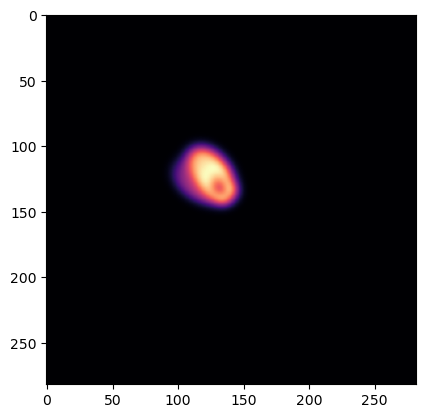

In [57]:
# Plotting Comparison
%matplotlib inline
image_index = 0
# Pinhole Projection Image
plt.imshow(images_blurred[image_index, :, :], cmap="magma")
# plt.savefig(f"projection_compare_{image_index}.png")
plt.show()

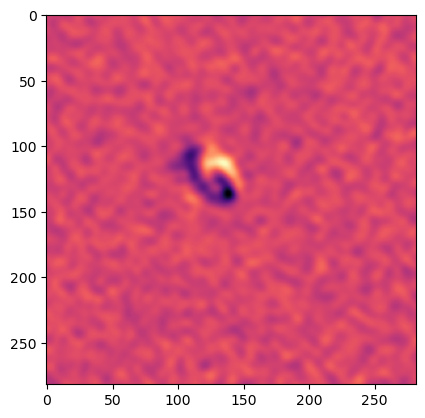

In [58]:
plt.imshow(data[image_index,:,:] - images_blurred[image_index, :, :], cmap="magma")

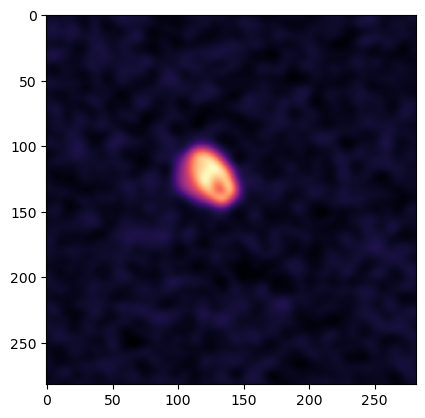

In [59]:
# Plotting Comparison
%matplotlib inline

image_index = 0

# Pinhole Projection Image
plt.imshow(images_noisy_blurred[image_index, :, :], cmap="magma")
# plt.savefig(f"projection_compare_{image_index}.png")
plt.show()

# Demo MCMC on synthetic observation

In [101]:
import inference 

param_index_dict = inference.DISK_PARAM_INDEX
################################################################################
# 1) Set up the single-parameter prior for v_turb
################################################################################
posterior_params = {
    param_index_dict['q']: {
        'bounds': [-0.5, 0.0],
        'p0_range': [-0.3, -0.1],
    },
    param_index_dict['log_r_c']: {
        'bounds': [1.75, 2.50],
        'p0_range': [2.00, 2.30],
    },
    param_index_dict['v_turb']: {
        'bounds': [0.0, 1.0],
        'p0_range': [0.05, 0.15],
    },
    param_index_dict['T_atm1']: {
        'bounds': [40.0, 150.0],
        'p0_range': [60.0, 110.0],
    },
    param_index_dict['T_mid1']: {
        'bounds': [5.0, 40.0],
        'p0_range': [10.0, 30.0],
    },
    param_index_dict['r_in']: {
        'bounds': [1.0, 20.0],
        'p0_range': [5.0, 15.0],
    },
    param_index_dict['r_break']: {
        'bounds': [15.0, 115.0],
        'p0_range': [50.0, 80.0],
    },
    param_index_dict['q_in']: {
        'bounds': [-1.0, 0.0],
        'p0_range': [-0.7, -0.3],
    }
}

# Our disk_params dictionary (already created), e.g.:
disk_params = parametric_disk.create_disk_params(
    T_mid1=17.8,
    T_atm1=87.0,
    q=-0.27,
    q_in=-0.57,
    r_break=70,
    M_star=2.3 * M_sun,
    gamma=1.0,
    r_in=11.0,
    log_r_c=2.3,
    M_gas=0.09 * M_sun,
    v_turb=0.3,  # Just an initial guess; the MCMC will sample this
    co_abundance=1e-4,
    N_dissoc=0.79 * 1.59e21,
    N_desorp=-np.inf,
    freezeout=19.0,
    r_scale=150.0,
    z_q0=70.0,
    delta=1,
    transition=2,
    m_mol=2.37 * m_h
)

ray_coords_sph = grid.cartesian_to_spherical(ray_coords_pinhole)
ray_coords_polar = grid.spherical_to_zr(ray_coords_sph)
energy_levels, radiative_transitions = line_rte.load_molecular_tables(
    path="/nfs/rhea.dgp/u8/d/len/code/radjax_updated/molecular_tables/molecule_12c16o.inp"
)

In [102]:
################################################################################
# 2) Create the sampler_dict for the new functional inference
################################################################################
sampler_dict = inference.create_sampler(
    z_disk=z_disk,
    r_disk=r_disk,
    bbox=bbox_disk,
    pixel_area=pixel_area_pinhole,
    ray_coords=ray_coords_pinhole,
    ray_coords_polar=grid.spherical_to_zr(grid.cartesian_to_spherical(ray_coords_pinhole)),
    obs_dir=obs_dir_pinhole,
    beam=beam,
    energy_levels=energy_levels,
    radiative_transitions=radiative_transitions,
    sigma=0.05,
    disk_params=disk_params,
    posterior_params=posterior_params,
    stride=None
)


In [103]:
################################################################################
# 3) Initialize the walkers
################################################################################
ndim = len(list(posterior_params.keys()))     # We have only one parameter: v_turb
nwalkers = 32
nsteps = 200 # Example number of MCMC steps

# Sample initial positions p0 from the param_bounds
p0 = inference.sample_p0(nwalkers, posterior_params, seed=1337)

In [104]:
################################################################################
# 4) Set up and run the emcee MCMC
################################################################################
backend = emcee.backends.HDFBackend("mcmc_v_turb_sampler.h5")
backend.reset(nwalkers, ndim)

def logprob_wrapper(params):
    """
    A small wrapper that calls the functional logprob with the 
    arguments we need: the data (images_ground_truth_blurred) 
    and frequencies, plus the sampler_dict.
    """
    return inference.logprob(params, images_noisy_blurred, freqs, sampler_dict)

sampler = emcee.EnsembleSampler(
    nwalkers=nwalkers,
    ndim=ndim,
    log_prob_fn=logprob_wrapper,
    backend=backend
)

print("Running MCMC...")
start_time_mcmc = time.time()
sampler.run_mcmc(p0, nsteps, progress=True)
end_time_mcmc = time.time()
mcmc_time = end_time_mcmc - start_time_mcmc
print(f"MCMC completed in {mcmc_time:.2f} seconds.")

Running MCMC...
updated Traced<ShapedArray(float64[], weak_type=True)>with<DynamicJaxprTrace(level=1/0)> to Traced<ShapedArray(float64[])>with<DynamicJaxprTrace(level=1/0)>
updated Traced<ShapedArray(float64[], weak_type=True)>with<DynamicJaxprTrace(level=1/0)> to Traced<ShapedArray(float64[])>with<DynamicJaxprTrace(level=1/0)>
updated Traced<ShapedArray(float64[], weak_type=True)>with<DynamicJaxprTrace(level=1/0)> to Traced<ShapedArray(float64[])>with<DynamicJaxprTrace(level=1/0)>
updated Traced<ShapedArray(float64[], weak_type=True)>with<DynamicJaxprTrace(level=1/0)> to Traced<ShapedArray(float64[])>with<DynamicJaxprTrace(level=1/0)>
updated Traced<ShapedArray(int64[], weak_type=True)>with<DynamicJaxprTrace(level=1/0)> to Traced<ShapedArray(float64[])>with<DynamicJaxprTrace(level=1/0)>
updated Traced<ShapedArray(float64[], weak_type=True)>with<DynamicJaxprTrace(level=1/0)> to Traced<ShapedArray(float64[])>with<DynamicJaxprTrace(level=1/0)>
updated Traced<ShapedArray(float64[], weak_t

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [49:58<00:00, 14.99s/it]

MCMC completed in 3014.74 seconds.


In [131]:
################################################################################
# 6) Update the disk_params with the MCMC result and re-render
################################################################################
samples = sampler.get_chain(flat=True)

# Compute residual metrics for MCMC
v_turb_median = np.median(samples[:, 0])
v_turb_16th, v_turb_84th = np.percentile(samples[:, 0], [16, 84])

# Update the disk with the recovered v_turb
disk_params["v_turb"] = v_turb_median

# Recompute temperature and densities with updated v_turb
temperature_mcmc = parametric_disk.temperature_profile(z_disk, r_disk, disk_params)
nd_h2_mcmc = parametric_disk.number_density_profile(
    z_disk,
    r_disk,
    temperature_mcmc,
    disk_params["gamma"],
    disk_params["r_in"],
    10 ** disk_params["log_r_c"],
    disk_params["M_gas"],
    disk_params["M_star"],
    disk_params["m_mol"]
)

velocity_az_mcmc = -parametric_disk.velocity_profile(
    z_disk, r_disk, nd_h2_mcmc, temperature_mcmc, disk_params
)

N_h2_mcmc = parametric_disk.surface_density(z_disk, nd_h2_mcmc)
abundance_co_mcmc = parametric_disk.co_abundance_profile(N_h2_mcmc, temperature_mcmc, disk_params)
nd_co_mcmc = abundance_co_mcmc * nd_h2_mcmc

# Render new cube with the updated v_turb
images_mcmc = render_cube_pinhole(
    ray_coords=ray_coords_pinhole,
    pixel_area=pixel_area_pinhole,
    disk_params=disk_params,       # pass the dictionary instead of a disk object
    nd_co=nd_co_mcmc,
    temperature=temperature_mcmc,
    velocity_az=velocity_az_mcmc,
    bbox=bbox_disk,
    freqs=freqs,
    nu0=nu0,
    obs_dir=obs_dir_pinhole,
    molecular_table=molecular_table
)

images_mcmc_blurred = sensor.fftconvolve_vmap(images_mcmc, beam)

residual_mcmc = images_noisy_blurred - images_mcmc_blurred
chi2_mcmc = np.sum(((images_noisy_blurred - images_mcmc_blurred) / 0.05)**2)
residual_sum_mcmc = np.sum(np.abs(residual_mcmc))
residual_mean_mcmc = np.mean(np.abs(residual_mcmc))

n_data = np.prod(data.shape)
chi_squared_over_n_data = chi2_mcmc / n_data

print(f"MCMC Chi-squared: {chi2_mcmc:.2f}, Chi-squared/N_data = {chi_squared_over_n_data}")
print(f"MCMC Residual Sum: {residual_sum_mcmc:.2f}")
print(f"MCMC Residual Mean: {residual_mean_mcmc:.2f}")

computing pinhole spectral cube for a total of 50 frequencies
MCMC Chi-squared: 35268059.39, Chi-squared/N_data = 8.869790098491512
MCMC Residual Sum: 289384.07
MCMC Residual Mean: 0.07


<IPython.core.display.Javascript object>


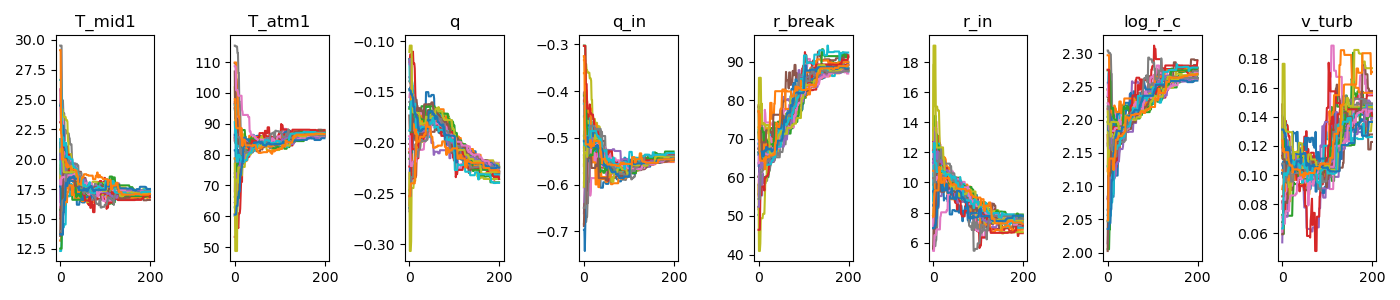

In [124]:
chain = sampler.get_chain()

ndim = chain.shape[-1]
param_labels = [
    inference.REV_DISK_PARAM_INDEX[idx] for idx in sorted(posterior_params.keys())
]

%matplotlib notebook
fig, axes = plt.subplots(1, ndim, figsize=(14,3))
for i in range(ndim):
    axes[i].plot(chain[...,i])
    axes[i].set_title(param_labels[i])

plt.tight_layout()

Flat samples shape: (3200, 8)


<IPython.core.display.Javascript object>


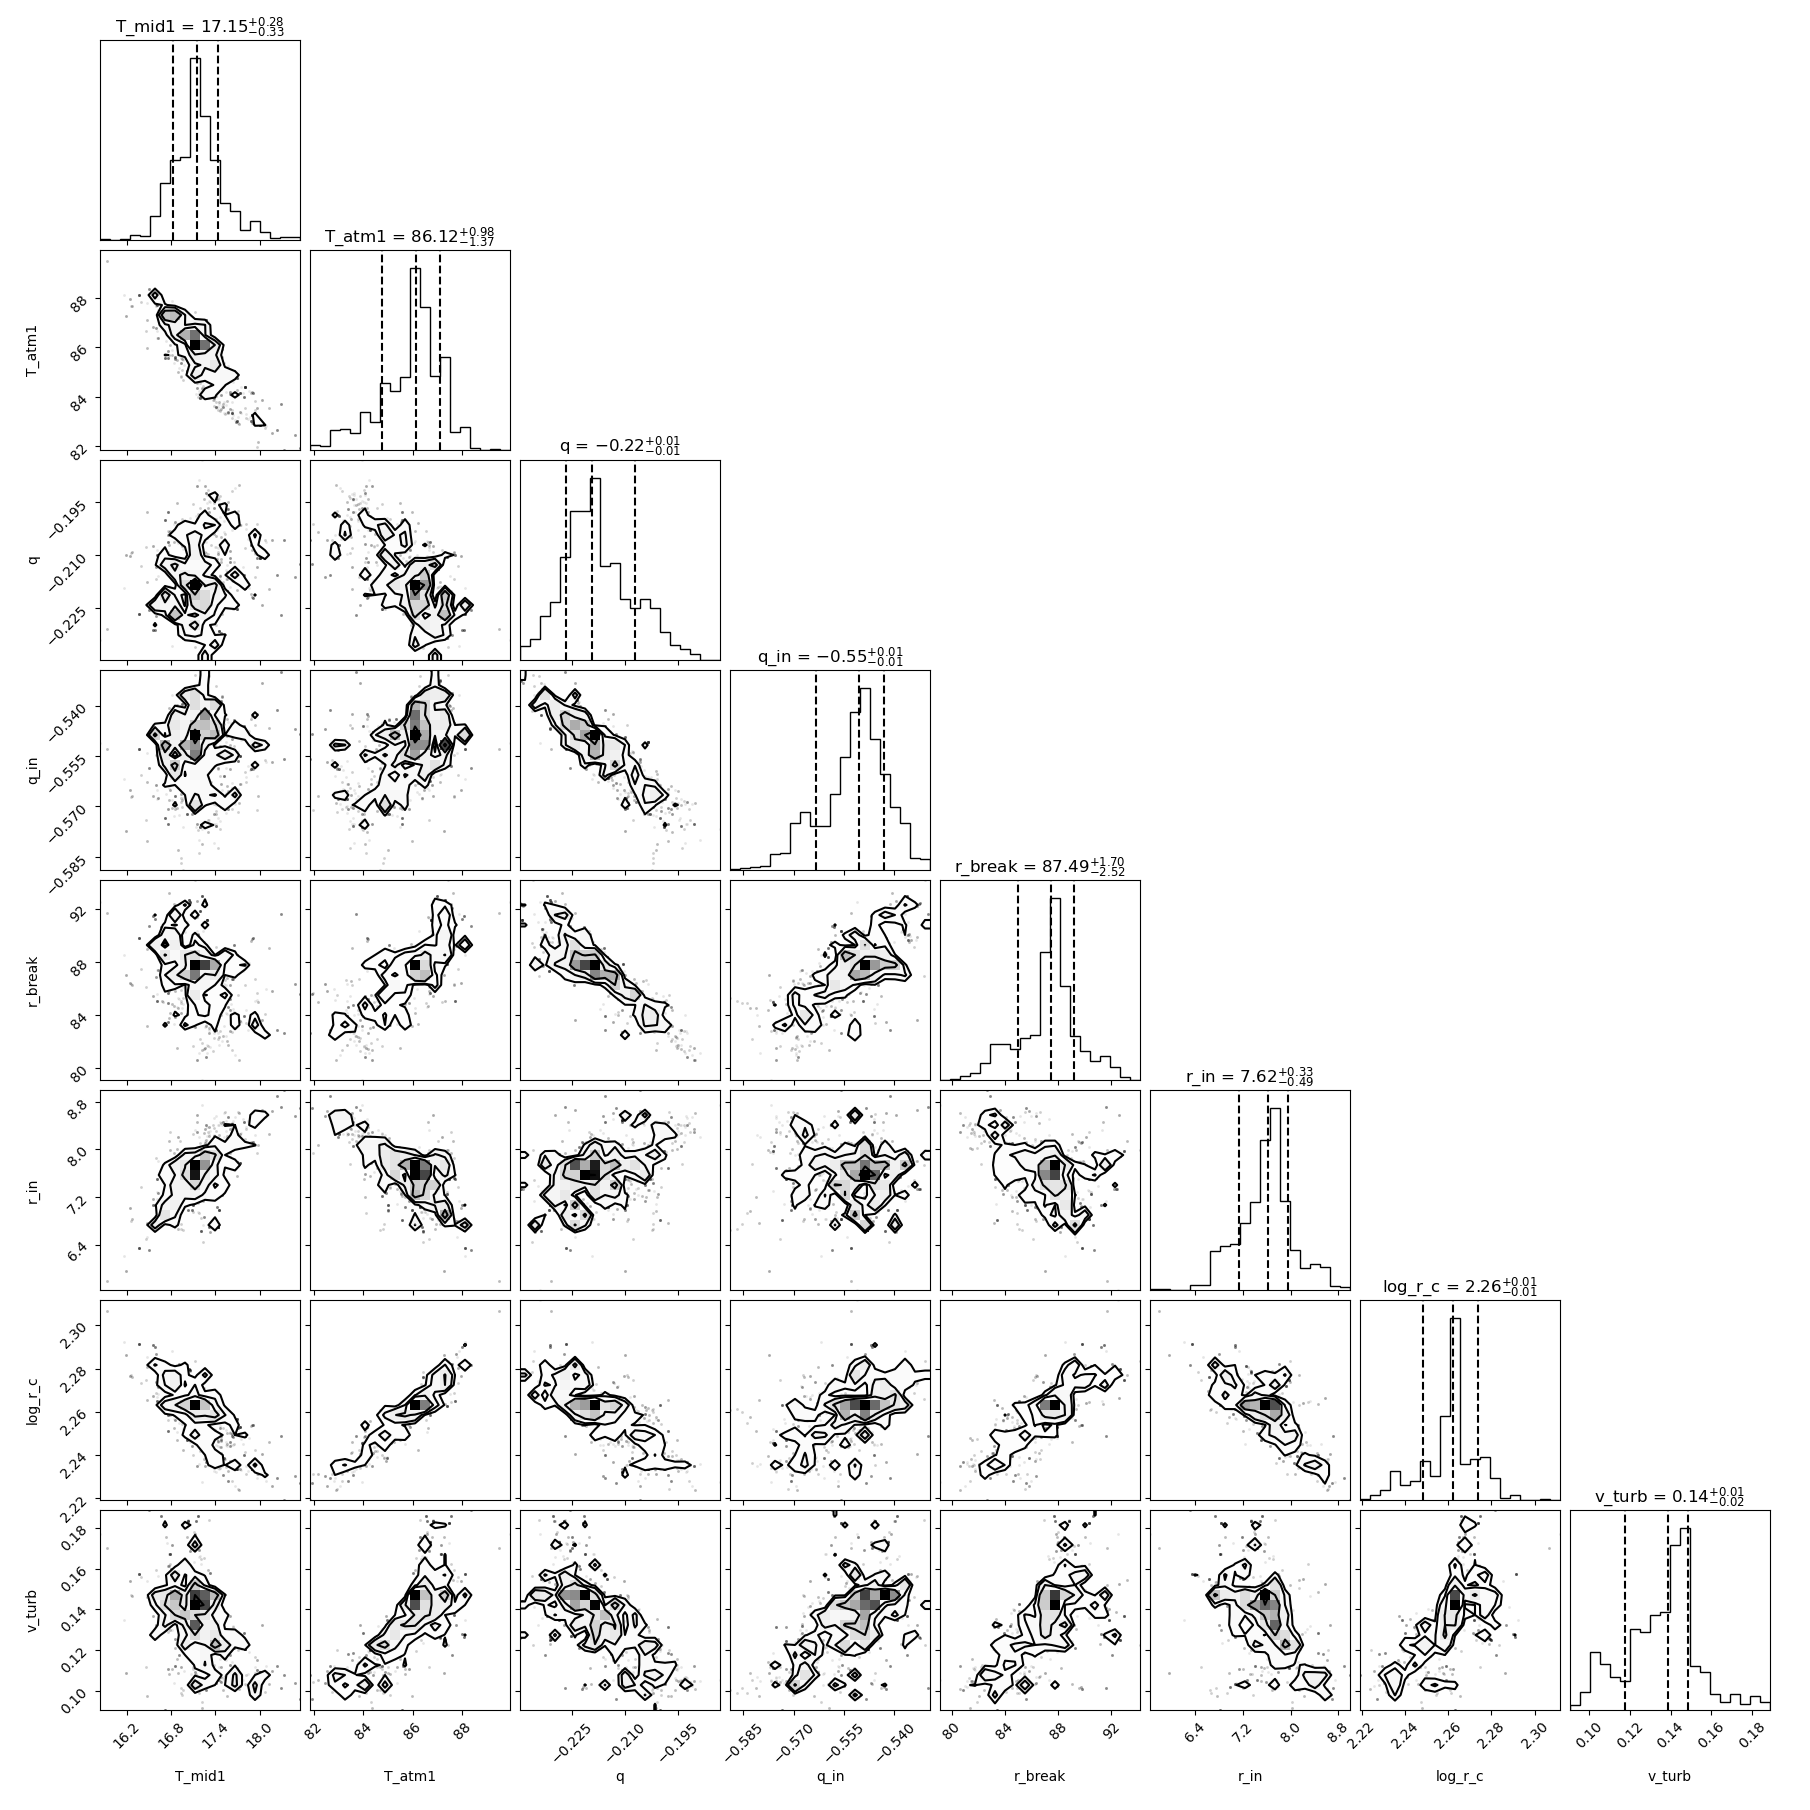

In [123]:
%matplotlib notebook
import corner

# Discard first 100 steps, flatten the rest
flat_samples = sampler.get_chain(discard=100, thin=1, flat=True)
print("Flat samples shape:", flat_samples.shape)  # should be ((nsteps-100)*nwalkers, ndim)

param_labels = [
    inference.REV_DISK_PARAM_INDEX[idx] for idx in sorted(posterior_params.keys())
]

# corner plot
fig = corner.corner(
    flat_samples,
    labels=param_labels,
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True
)

In [128]:
burnin = 100  # example number of steps to discard
flat_samples = sampler.get_chain(discard=burnin, flat=True)
# shape is ((nsteps-burnin)*nwalkers, ndim)

print("flat_samples shape:", flat_samples.shape)

ground_truth = {
    "q": -0.27,
    "log_r_c": 2.3,
    "v_turb": 0.06,
    "T_atm1": 87.0,
    "T_mid1": 17.8,
    "r_in": 11.0,
    "r_break": 70.0,
    "q_in": -0.57
}

# for i, label in enumerate(param_labels):
#     p16, p50, p84 = np.percentile(flat_samples[:, i], [16, 50, 84])
#     median_val = p50
#     minus_err = p50 - p16
#     plus_err  = p84 - p50
#     print(f"{label:8s}: {median_val:.3f} +{plus_err:.3f} -{minus_err:.3f}")
    
for i, label in enumerate(param_labels):
    gt_val = ground_truth[label]  # ground truth
    p16, p50, p84 = np.percentile(flat_samples[:, i], [16, 50, 84])
    print(f"{label:8s} | True: {gt_val:.3f} "
          f"| MCMC: {p50:.3f} (+{p84 - p50:.3f} / -{p50 - p16:.3f})")

flat_samples shape: (3200, 8)
T_mid1   | True: 17.800 | MCMC: 17.146 (+0.285 / -0.327)
T_atm1   | True: 87.000 | MCMC: 86.125 (+0.981 / -1.371)
q        | True: -0.270 | MCMC: -0.219 (+0.012 / -0.007)
q_in     | True: -0.570 | MCMC: -0.551 (+0.007 / -0.013)
r_break  | True: 70.000 | MCMC: 87.490 (+1.702 / -2.515)
r_in     | True: 11.000 | MCMC: 7.618 (+0.328 / -0.489)
log_r_c  | True: 2.300 | MCMC: 2.262 (+0.012 / -0.014)
v_turb   | True: 0.060 | MCMC: 0.139 (+0.010 / -0.021)


## MCMC on Flaherty observation

Running MCMC...


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 400/400 [2:36:24<00:00, 23.46s/it]

MCMC completed in 9408.71 seconds.


<IPython.core.display.Javascript object>


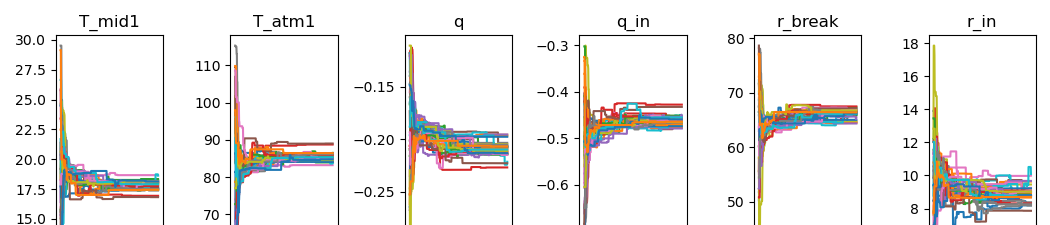

Flat samples shape: (9600, 8)


<IPython.core.display.Javascript object>


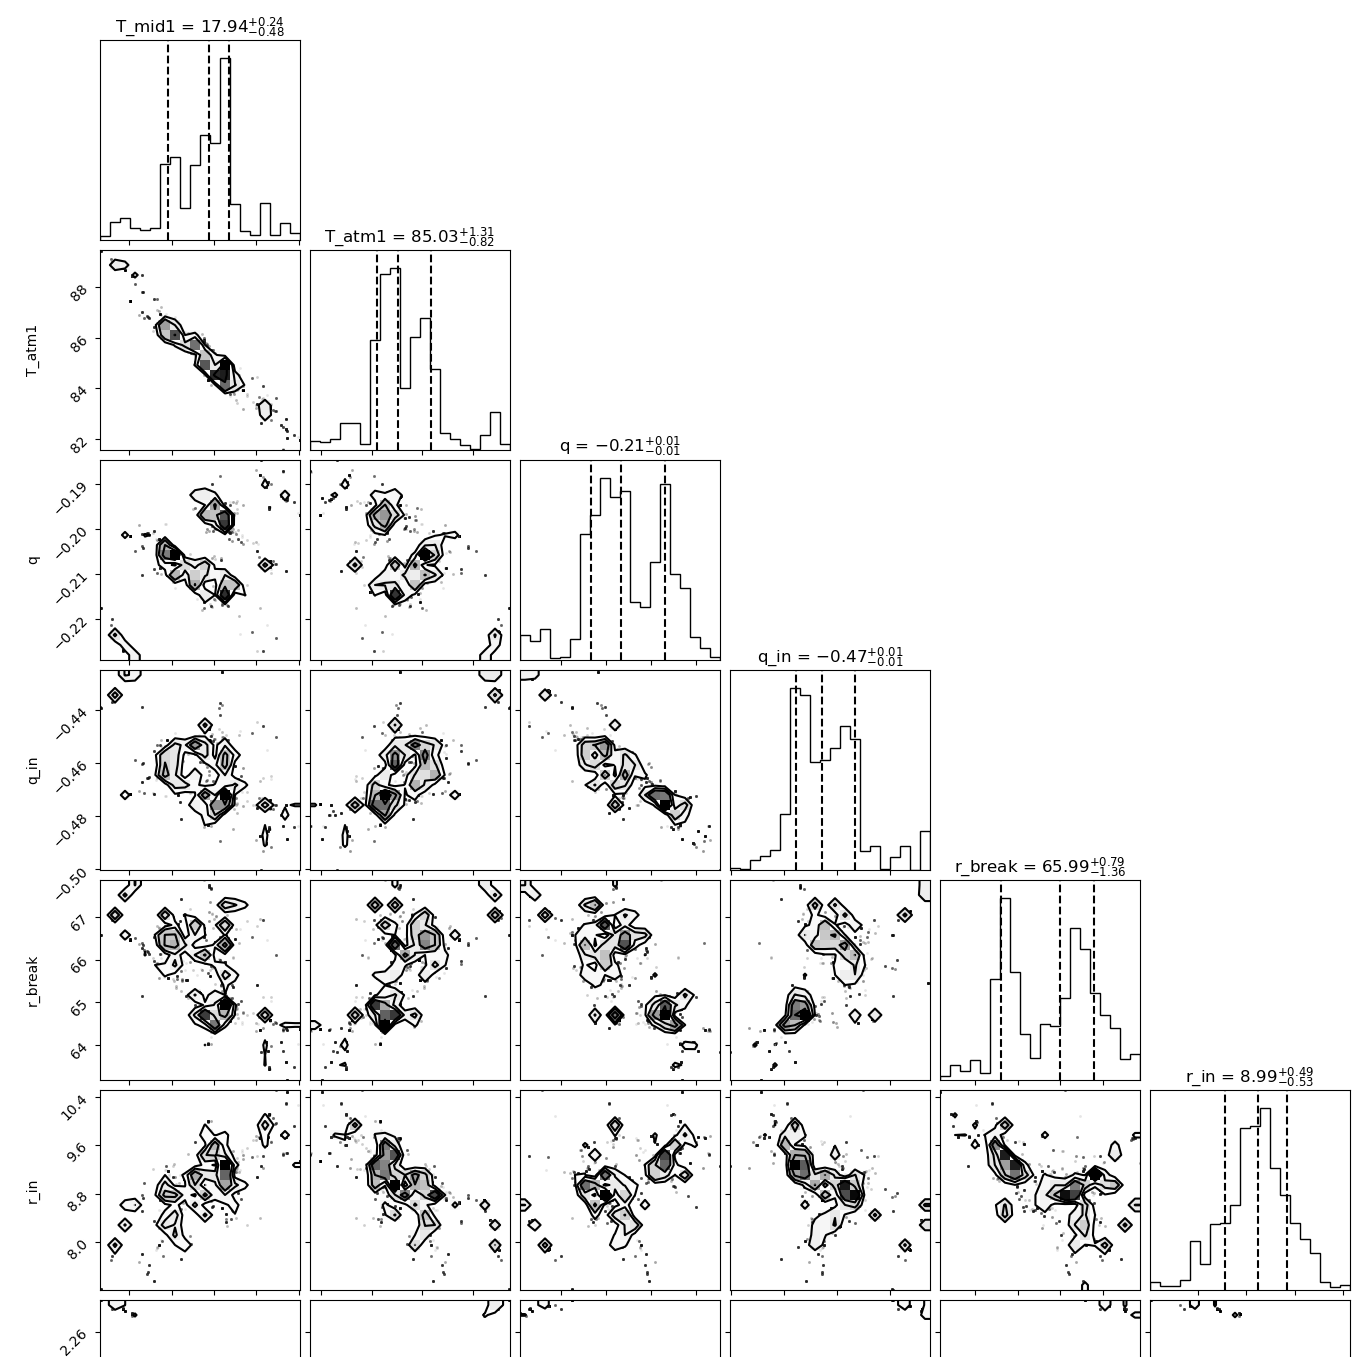

flat_samples shape: (9600, 8)
T_mid1   | True: 17.800 | MCMC: 17.942 (+0.237 / -0.484)
T_atm1   | True: 87.000 | MCMC: 85.029 (+1.308 / -0.817)
q        | True: -0.270 | MCMC: -0.207 (+0.010 / -0.007)
q_in     | True: -0.570 | MCMC: -0.466 (+0.012 / -0.010)
r_break  | True: 70.000 | MCMC: 65.988 (+0.790 / -1.364)
r_in     | True: 11.000 | MCMC: 8.987 (+0.486 / -0.535)
log_r_c  | True: 2.300 | MCMC: 2.242 (+0.002 / -0.021)
v_turb   | True: 0.060 | MCMC: 0.123 (+0.005 / -0.008)


In [60]:
import inference 

param_index_dict = inference.DISK_PARAM_INDEX
################################################################################
# 1) Set up the single-parameter prior for v_turb
################################################################################
posterior_params = {
    param_index_dict['q']: {
        'bounds': [-0.5, 0.0],
        'p0_range': [-0.3, -0.1],
    },
    param_index_dict['log_r_c']: {
        'bounds': [1.75, 2.50],
        'p0_range': [2.00, 2.30],
    },
    param_index_dict['v_turb']: {
        'bounds': [0.0, 1.0],
        'p0_range': [0.01, 0.2],
    },
    param_index_dict['T_atm1']: {
        'bounds': [40.0, 150.0],
        'p0_range': [60.0, 110.0],
    },
    param_index_dict['T_mid1']: {
        'bounds': [5.0, 40.0],
        'p0_range': [10.0, 30.0],
    },
    param_index_dict['r_in']: {
        'bounds': [1.0, 20.0],
        'p0_range': [5.0, 15.0],
    },
    param_index_dict['r_break']: {
        'bounds': [15.0, 115.0],
        'p0_range': [50.0, 80.0],
    },
    param_index_dict['q_in']: {
        'bounds': [-1.0, 0.0],
        'p0_range': [-0.7, -0.3],
    }
}

# Our disk_params dictionary (already created), e.g.:
disk_params = parametric_disk.create_disk_params(
    T_mid1=17.8,
    T_atm1=87.0,
    q=-0.27,
    q_in=-0.57,
    r_break=70,
    M_star=2.3 * M_sun,
    gamma=1.0,
    r_in=11.0,
    log_r_c=2.3,
    M_gas=0.09 * M_sun,
    v_turb=0.3,  # Just an initial guess; the MCMC will sample this
    co_abundance=1e-4,
    N_dissoc=0.79 * 1.59e21,
    N_desorp=-np.inf,
    freezeout=19.0,
    r_scale=150.0,
    z_q0=70.0,
    delta=1,
    transition=2,
    m_mol=2.37 * m_h
)

ray_coords_sph = grid.cartesian_to_spherical(ray_coords_pinhole)
ray_coords_polar = grid.spherical_to_zr(ray_coords_sph)
energy_levels, radiative_transitions = line_rte.load_molecular_tables(
    path="/nfs/rhea.dgp/u8/d/len/code/radjax_updated/molecular_tables/molecule_12c16o.inp"
)

################################################################################
# 2) Create the sampler_dict for the new functional inference
################################################################################
sampler_dict = inference.create_sampler(
    z_disk=z_disk,
    r_disk=r_disk,
    bbox=bbox_disk,
    pixel_area=pixel_area_pinhole,
    ray_coords=ray_coords_pinhole,
    ray_coords_polar=grid.spherical_to_zr(grid.cartesian_to_spherical(ray_coords_pinhole)),
    obs_dir=obs_dir_pinhole,
    beam=beam,
    energy_levels=energy_levels,
    radiative_transitions=radiative_transitions,
    sigma=0.05,
    disk_params=disk_params,
    posterior_params=posterior_params,
    stride=None
)

################################################################################
# 3) Initialize the walkers
################################################################################
ndim = len(list(posterior_params.keys()))     # We have only one parameter: v_turb
nwalkers = 32
nsteps = 400 # Example number of MCMC steps

# Sample initial positions p0 from the param_bounds
p0 = inference.sample_p0(nwalkers, posterior_params, seed=1337)

################################################################################
# 4) Set up and run the emcee MCMC
################################################################################
backend = emcee.backends.HDFBackend("mcmc_v_turb_sampler.h5")
backend.reset(nwalkers, ndim)

def logprob_wrapper(params):
    """
    A small wrapper that calls the functional logprob with the 
    arguments we need: the data (images_ground_truth_blurred) 
    and frequencies, plus the sampler_dict.
    """
    return inference.logprob(params, data, freqs, sampler_dict)

sampler = emcee.EnsembleSampler(
    nwalkers=nwalkers,
    ndim=ndim,
    log_prob_fn=logprob_wrapper,
    backend=backend
)

print("Running MCMC...")
start_time_mcmc = time.time()
sampler.run_mcmc(p0, nsteps, progress=True)
end_time_mcmc = time.time()
mcmc_time = end_time_mcmc - start_time_mcmc
print(f"MCMC completed in {mcmc_time:.2f} seconds.")

chain = sampler.get_chain()

ndim = chain.shape[-1]
param_labels = [
    inference.REV_DISK_PARAM_INDEX[idx] for idx in sorted(posterior_params.keys())
]

%matplotlib notebook
fig, axes = plt.subplots(1, ndim, figsize=(14,3))
for i in range(ndim):
    axes[i].plot(chain[...,i])
    axes[i].set_title(param_labels[i])

plt.tight_layout()

%matplotlib notebook
import corner

# Discard first 100 steps, flatten the rest
flat_samples = sampler.get_chain(discard=100, thin=1, flat=True)
print("Flat samples shape:", flat_samples.shape)  # should be ((nsteps-100)*nwalkers, ndim)

param_labels = [
    inference.REV_DISK_PARAM_INDEX[idx] for idx in sorted(posterior_params.keys())
]

# corner plot
fig = corner.corner(
    flat_samples,
    labels=param_labels,
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True
)

burnin = 100  # example number of steps to discard
flat_samples = sampler.get_chain(discard=burnin, flat=True)
# shape is ((nsteps-burnin)*nwalkers, ndim)

print("flat_samples shape:", flat_samples.shape)

ground_truth = {
    "q": -0.27,
    "log_r_c": 2.3,
    "v_turb": 0.06,
    "T_atm1": 87.0,
    "T_mid1": 17.8,
    "r_in": 11.0,
    "r_break": 70.0,
    "q_in": -0.57
}

# for i, label in enumerate(param_labels):
#     p16, p50, p84 = np.percentile(flat_samples[:, i], [16, 50, 84])
#     median_val = p50
#     minus_err = p50 - p16
#     plus_err  = p84 - p50
#     print(f"{label:8s}: {median_val:.3f} +{plus_err:.3f} -{minus_err:.3f}")
    
for i, label in enumerate(param_labels):
    gt_val = ground_truth[label]  # ground truth
    p16, p50, p84 = np.percentile(flat_samples[:, i], [16, 50, 84])
    print(f"{label:8s} | True (Flaherty 2018): {gt_val:.3f} "
          f"| MCMC: {p50:.3f} (+{p84 - p50:.3f} / -{p50 - p16:.3f})")

In [62]:
ground_truth = {
    "q": -0.27,
    "log_r_c": 2.3,
    "v_turb": 0.06,
    "T_atm1": 87.0,
    "T_mid1": 17.8,
    "r_in": 11.0,
    "r_break": 70.0,
    "q_in": -0.57
}

for i, label in enumerate(param_labels):
    gt_val = ground_truth[label]  # ground truth
    p16, p50, p84 = np.percentile(flat_samples[:, i], [16, 50, 84])
    print(f"{label:8s} | True (Flaherty 2018): {gt_val:.3f} "
          f"| MCMC: {p50:.3f} (+{p84 - p50:.3f} / -{p50 - p16:.3f})")

T_mid1   | True (Flaherty 2018): 17.800 | MCMC: 17.942 (+0.237 / -0.484)
T_atm1   | True (Flaherty 2018): 87.000 | MCMC: 85.029 (+1.308 / -0.817)
q        | True (Flaherty 2018): -0.270 | MCMC: -0.207 (+0.010 / -0.007)
q_in     | True (Flaherty 2018): -0.570 | MCMC: -0.466 (+0.012 / -0.010)
r_break  | True (Flaherty 2018): 70.000 | MCMC: 65.988 (+0.790 / -1.364)
r_in     | True (Flaherty 2018): 11.000 | MCMC: 8.987 (+0.486 / -0.535)
log_r_c  | True (Flaherty 2018): 2.300 | MCMC: 2.242 (+0.002 / -0.021)
v_turb   | True (Flaherty 2018): 0.060 | MCMC: 0.123 (+0.005 / -0.008)


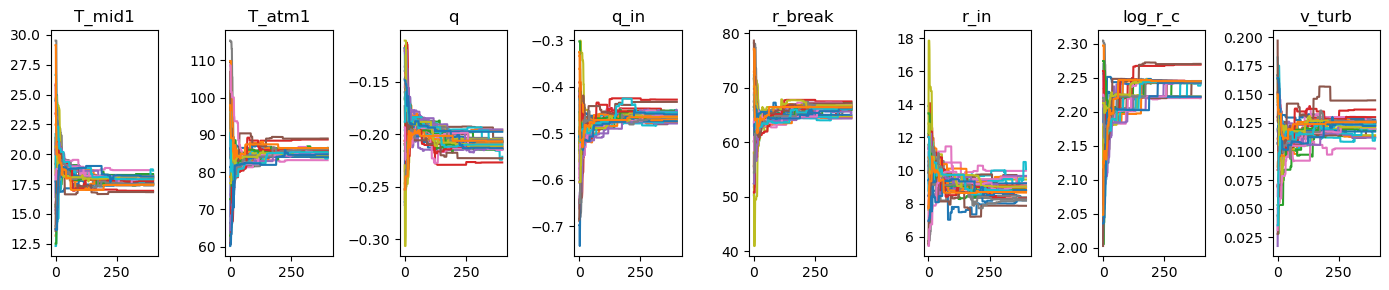

In [65]:
%matplotlib inline
fig, axes = plt.subplots(1, ndim, figsize=(14,3))
for i in range(ndim):
    axes[i].plot(chain[...,i])
    axes[i].set_title(param_labels[i])

plt.tight_layout()

Flat samples shape: (9600, 8)


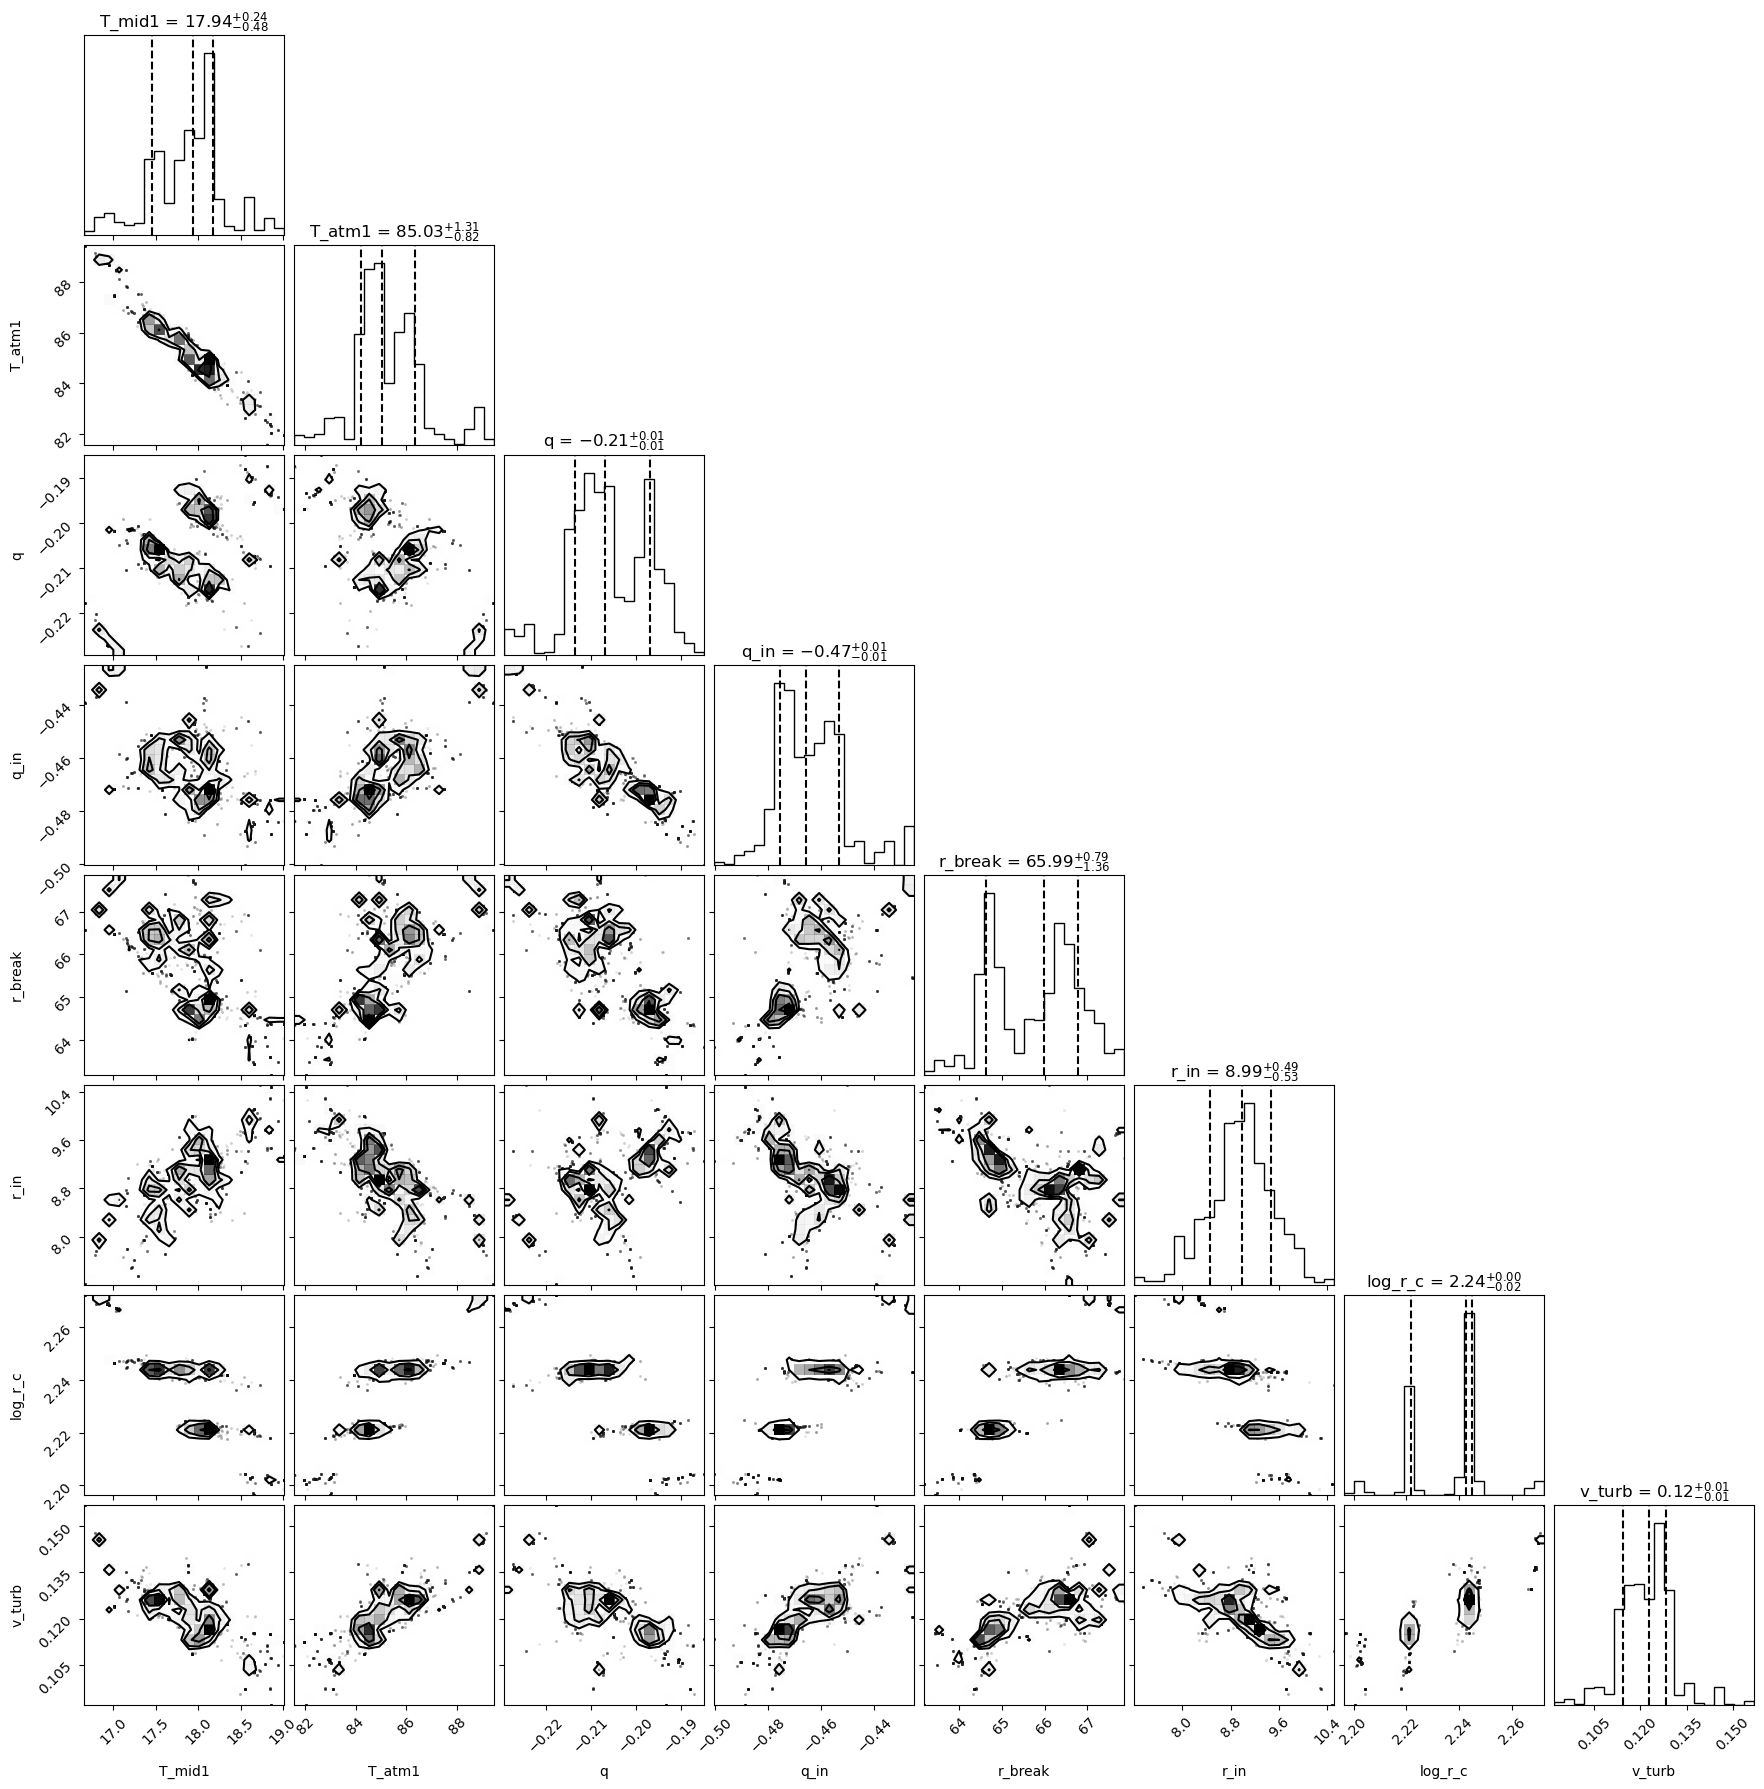

In [66]:
%matplotlib inline
import corner

# Discard first 100 steps, flatten the rest
flat_samples = sampler.get_chain(discard=100, thin=1, flat=True)
print("Flat samples shape:", flat_samples.shape)  # should be ((nsteps-100)*nwalkers, ndim)

param_labels = [
    inference.REV_DISK_PARAM_INDEX[idx] for idx in sorted(posterior_params.keys())
]

# corner plot
fig = corner.corner(
    flat_samples,
    labels=param_labels,
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True
)